#### Author : Divya Swaminathan
##### March 2026

### The goal of this turorial is to implement Linear Regression from scratch

> Main Things one needs to know while implementing an ML algorithm

* Model y = f(X)
  * For Linear Regression - Model f(X) = X*W + bias
---  
* Cost or Loss function for the model.
  * Loss is  mean squared error function ; mse = (y - f(X))^2/ num_samples
---      
* What variables in f(X) is our algorithm learning?
  * For linear regression the algorithm is learning slope (W; weights) and intercept (b; bias)
---      
* What learning algorithm is being used ?
  * Gradient Descent.
---      
* Since we are using Gradient Descent - it becomes very important to understand the derivative of the loss function with respect to the variables one is trying to learn.
  
    * derivative of loss function wrt weights =  \
         2(y-f(X))(y-f(X))' = \
         2(y-f(X))(y -XW -bias)' = \
         2(y - f(X))(-X) = \
         -2X(y-f(X)) / num_samples
      
    * derivative of loss function wrt bias =    -2(y-f(X)) / num_samples
    * derivative  of loss function with respect to slope & intercept (linear regression) should be minimized for gradient descent.
    * Gradient descent stops when the slope is close to zero.
---  
* <b> When you program  the algorithm from scratch pay close attention to dimensionality at every step.</b>


###  Vector Dimensionality

* X : num_samples x num_features ; X.T = num_features x num_samples
* y : num_samples x 1
* weights : num_features x 1 ; bias = scalar
* forward pass / predict / f(X)  :  X.dot(weights) + bias.
    * (num_samples x num_features) x (num_features x 1) + bias = num_samples x1
* loss: num_samples x 1
* difference/ error =  actual - predict = y - forward pass =   num_samples x 1
* gradient wrt weights = -2X(y-f(X)) / num_samples.
    * np.dot(X.T, difference) --> num_features x 1
* gradient wrt biast = np.sum(difference) --> scalar


### Programming notes for writing ML algo's from scratch

* We will write a class for the model f(X)
* The class will have 5 functions :-
  * Initialization - initialize with learning rate and number of iterations one would like the model to take to learn.
  * Forward pass or predict - function to calculate y_pred.
  * Loss function
  * Gradients - function codes for gradients wrt weights and bias
  * Update - function to update the weights / bias.
  * Fit - function that fits the model to incoming data.

* Functions prefixed by <i>__name</i> are internal to the class. By convention should not be accessed from outside the class. Therefore one writes functions for loss, gradients and update with <i>__loss</i>, <i>__gradient</i> etc.

* Functions like predict and fit will be accessed from outside the class and will be used to evaluate how well the model works on chosen data.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

> ### The Linear Regression Class

In [7]:
class LinearRegression():

    def __init__(self, learning_rate = 0.01, iterations = 100):
        self.lr = learning_rate
        self.epochs = iterations

    def __loss(self, X, y):
        "Loss or Error function"
        loss =  np.mean((y - self.forward(X))**2)
        return loss
    
    def __gradients(self,X,y,h):
        "Function calculates gradient wrt weights and bias"
        error = y-h
        d_weights  = (-2/self.num_samples)* np.dot(X.T, error)
        d_bias = (-2/self.num_samples)*np.sum(error)
        return d_weights, d_bias

    def __update(self,d_weights, d_bias):
        "Function updates weights and bias"
        self.weights-= self.lr* d_weights
        self.bias-= self.lr* d_bias
        return

    def forward(self,X):
        "Prediction function. Just use f(X)"
        return X.dot(self.weights)+self.bias


    def fit(self,X,y):
        "Function fits model to data"
        
        self.num_samples = X.shape[0]
        self.weights, self.bias = np.zeros((X.shape[1],1)), 0
        y = y.reshape(-1,1)

        for ep in range(self.epochs):
            y_pred = self.forward(X)
            d_weights, d_bias = self.__gradients(X,y, y_pred)
            self.__update(d_weights,d_bias)

            if ep%10 ==0:
                print('Loss is', self.__loss(X,y))        
        

#### Let's take a dataset from sklearn and test our linear regression model

* Not working great as predicted target value is fluctuating around 150
* A deeper dive will follow in another tutorial

In [8]:
from sklearn.datasets import load_diabetes #fetch_california_housing
from sklearn.model_selection import train_test_split

In [9]:
data = load_diabetes()
print(data.data.shape, data.target.shape)

X = data.data
y = data.target

(442, 10) (442,)


<!-- >  Lets use only 1 feature for predictions.

This is just to make life easier. Play with which one feature you would like to work with. -->


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, test_size =0.2 , random_state= 20)

In [11]:
### Use the model

model = LinearRegression(learning_rate = 0.01, iterations = 500)
model.fit(X_train, y_train)
predictions = model.forward(X_test)

Loss is 28882.229163301115
Loss is 21231.283602316107
Loss is 16120.914636811352
Loss is 12706.656727632017
Loss is 10424.740010448193
Loss is 8898.788596475317
Loss is 7877.531845173449
Loss is 7193.220067511846
Loss is 6733.8626208872565
Loss is 6424.693908689172
Loss is 6215.799979731406
Loss is 6073.857978018109
Loss is 5976.621354000511
Loss is 5909.238161297857
Loss is 5861.793131350346
Loss is 5827.666748946303
Loss is 5802.439762023948
Loss is 5783.161826392977
Loss is 5767.863248930238
Loss is 5755.229024652941
Loss is 5744.3812220766295
Loss is 5734.733702483629
Loss is 5725.895129707726
Loss is 5717.604218932936
Loss is 5709.686508435291
Loss is 5702.0255001596925
Loss is 5694.543393010027
Loss is 5687.188220287417
Loss is 5679.925262572932
Loss is 5672.7313149205565
Loss is 5665.590859603359
Loss is 5658.493511017444
Loss is 5651.432309885477
Loss is 5644.40258445721
Loss is 5637.401190240382
Loss is 5630.426002440545
Loss is 5623.475577110767
Loss is 5616.54892493298
Loss 

Text(0.5, 1.0, 'Out of the box performance on Diabetes dataset not great')

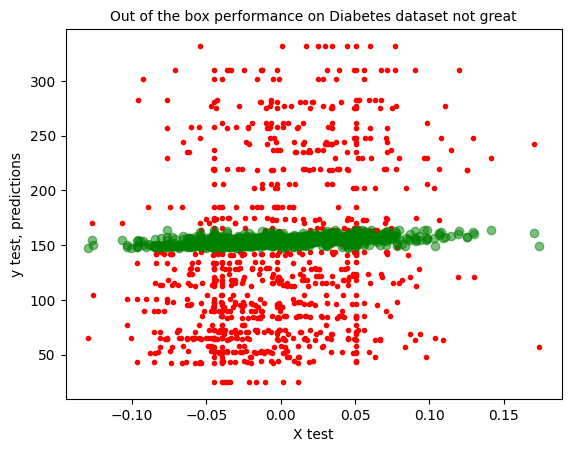

In [21]:
plt.plot(X_test,y_test,'r.', label =  'Test Set')
plt.xlabel('X test')
plt.ylabel('y test, predictions')
plt.plot(X_test,predictions,'go', alpha = 0.5, label =  'Predictions')
plt.title('Out of the box performance on Diabetes dataset not great', fontsize = 10)


### Try another dataset

In [22]:
del X,y, X_train, X_test, y_train, y_test

In [25]:
from pathlib import Path

In [26]:
path_to_training_data = Path('/Users/divyaswaminathan/Desktop/Main/Data Science/NoLibsML/Linear_Regression/energy_data

'/Users/divyaswaminathan/Desktop/Main/Data Science/NoLibsML/Linear_Regression'

In [27]:
ls

LinearRegression_scratch.ipynb  notes.md
energy_dataset/                 notes.txt
